In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/Users/devin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
pd.options.display.max_rows = None
pd.options.display.max_columns = None

In [5]:
df = pd.read_csv('../data/curated/visualisation_df.csv')

In [6]:
df['id'] = df['id'].str.extract(r'[A-Z]{4}(\d{5})')[0].astype(int)

In [7]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
id,72,380,610,862,2091,2227,2335,2636,2906,3530
region,Navaldia,Navaldia,Navaldia,Navaldia,Lyndrassia,Lyndrassia,Lyndrassia,Flumevale,Flumevale,Lyndrassia
regulated_dam,Yes,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes
primary_purpose,Recreation,NaN,Recreation,NaN,Recreation,Recreation,Recreation,Water Supply,NaN,Water Supply
primary_type,Earth,Earth,Earth,NaN,Earth,Earth,Earth,Concrete,Earth,Earth
height,NaN,2.713,NaN,NaN,13.921,14.332,12.526,2.018,NaN,26.547
length,NaN,NaN,NaN,NaN,0.2,0.127,0.17,0.017,0.082,0.933
volume,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15650.0,NaN
surface,0.02364,NaN,NaN,NaN,0.04728,0.06107,0.04137,NaN,0.01773,19.1484
drainage,2.66329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## region

In [8]:
df.groupby('region')['regulated_dam'].value_counts()

region      regulated_dam
Flumevale   Yes              3257
            No                265
Lyndrassia  No               5013
            Yes              3393
Navaldia    Yes              5402
            No               3476
Name: count, dtype: int64

the ratio of regulated_dam is very high in Flemevale, then Navaldia, the lowest is Lyndrassia

In [9]:
df.groupby('region')['primary_purpose'].value_counts()

region      primary_purpose                           
Flumevale   Water Supply                                  1025
            Irrigation                                     984
            Flood Risk Reduction                           425
            Hydroelectric                                  268
            Recreation                                     239
            Other                                          224
            Fish and Wildlife Pond                         131
            Fire Protection, Stock, Or Small Fish Pond     115
            Debris Control                                  51
            Tailings                                        15
Lyndrassia  Fire Protection, Stock, Or Small Fish Pond    2280
            Recreation                                    1918
            Flood Risk Reduction                          1232
            Irrigation                                    1112
            Grade Stabilization                            651


Fluemvale: most dams are for water supply and irrigation, probly due to high water demand for agriculture

Lyndrassia: Fire Protection, small fish pond, recreation, flood risk reduction, irrigation

Navaldia: Flood Risk Reduction, Recreation

In [10]:
df.groupby('region')['hazard'].value_counts()

region      hazard      
Flumevale   Low             1704
            High            1348
            Significant      470
Lyndrassia  Low             6326
            High            1699
            Significant      381
Navaldia    Low             5615
            High            2377
            Significant      873
            Undetermined      13
Name: count, dtype: int64

all undetermined-hazard dams is in Navaldia, why?
for all regions, most dams have low hazard, but Flumevale has relative high ratio of high-hazard dams
significant-hazard dams are few, probly significant means more damage than high?

In [11]:
df.groupby('region')['assessment'].value_counts()

region      assessment    
Flumevale   Satisfactory      1850
            Fair               650
            Not Rated          619
            Not Available      232
            Unsatisfactory     120
            Poor                51
Lyndrassia  Not Rated         4762
            Satisfactory       752
            Not Available      134
            Unsatisfactory      91
            Poor                82
            Fair                49
Navaldia    Not Rated         6199
            Fair              1389
            Satisfactory       677
            Poor               345
            Not Available      138
            Unsatisfactory     129
Name: count, dtype: int64

Flumevale: high ratio of satisfactory

## regulated_dam

In [12]:
df.groupby('regulated_dam')['assessment'].value_counts()

regulated_dam  assessment    
No             Not Rated         8029
               Not Available      422
               Poor                88
               Satisfactory        88
               Fair                69
               Unsatisfactory      57
Yes            Not Rated         3551
               Satisfactory      3191
               Fair              2019
               Poor               390
               Unsatisfactory     283
               Not Available       82
Name: count, dtype: int64

most unregulated dams don't do assessment

In [13]:
count = df.groupby('regulated_dam')['hazard'].value_counts()
round(count / count.groupby(level=0).transform('sum'), 2)

regulated_dam  hazard      
No             Low             0.80
               High            0.15
               Significant     0.05
               Undetermined    0.00
Yes            Low             0.55
               High            0.34
               Significant     0.11
Name: count, dtype: float64

regulated dams are tend to have higher hazard, probly due to regulated dams have larger size

In [14]:
df.groupby('regulated_dam')[['height', 'length', 'volume', 'surface', 'drainage', 'inspection_frequency', 'years_from_inspection', 'distance_to_nearest_city', 'probability_of_failure', 'dam_repair_loss', 'damage_loss' , 'business_interruption_loss', 'age', 'modification_count', 'years_from_modification', 'years_from_assessment']].describe()

height                                                \
                 count       mean        std    min      25%     50%   
regulated_dam                                                          
No              8748.0   9.529356   8.859270  0.346  6.74000  8.7605   
Yes            12034.0  12.545383  12.749499  1.062  6.41375  9.6280   

                                   length                                    \
                    75%      max    count      mean       std    min    25%   
regulated_dam                                                                 
No             10.43500  220.921   6025.0  0.312491  0.727269  0.001  0.140   
Yes            14.28275  278.646  11856.0  0.455244  1.730189  0.005  0.117   

                                      volume                               \
                 50%    75%      max   count           mean           std   
regulated_dam                                                               
No             0.193  0.285   23.967  3086.0  278640.282233  2.991841e+06   
Yes            0.233  0.470  156.870  4882.0  305366.794637  2.623782e+06   

                                                             surface  \
               min       25%      50%       75%          max   count   
regulated_dam                                                          
No             8.3  10572.75  16752.0   24428.5  125628000.0  7396.0   
Yes            1.0  28000.00  65000.0  130615.0  110551373.0  8742.0   

                                                                        \
                   mean        std      min      25%      50%      75%   
regulated_dam                                                            
No             3.233641  43.894670  0.00394  0.04137  0.07486  0.13002   
Yes            2.322264  36.597891  0.00197  0.08471  0.19109  0.48462   

                          drainage                                      \
                      max    count         mean           std      min   
regulated_dam                                                            
No             1562.07998   5643.0  5569.563326  53728.790474  2.66329   
Yes            3143.66296   7492.0   643.570947   7544.974441  2.66329   

                                                                \
                     25%        50%          75%           max   
regulated_dam                                                    
No             298.28848  924.16163  1993.472565  1.899088e+06   
Yes              7.98987   15.97974    50.602510  2.674529e+05   

              inspection_frequency                                          \
                             count      mean       std  min  25%  50%  75%   
regulated_dam                                                                
No                          8754.0  0.068986  0.223164  0.0  0.0  0.0  0.0   
Yes                        12052.0  0.330296  0.451714  0.0  0.0  0.2  0.5   

                   years_from_inspection                                   \
               max                 count       mean        std  min   25%   
regulated_dam                                                               
No             1.0                8222.0  45.311117  21.583359 -6.0  29.0   
Yes            2.0               11925.0  27.318491  30.378644  1.0   4.0   

                                 distance_to_nearest_city             \
                50%   75%    max                    count       mean   
regulated_dam                                                          
No             49.0  60.0  145.0                   3526.0  13.770289   
Yes             7.0  57.0  206.0                   7051.0  22.816527   

                                                          \
                     std  min  25%    50%    75%     max   
regulated_dam                                              
No             20.666516  0.0  0.0   6.40  19.71  176.65   
Yes            27.610859  0.0  3.2  13.02  32.35  231.60   



regulated: length min = 5 m, height min = 1 m, volume min = 1 m3, 
much higher_damage loss adn business_interruption_loss, 
slightly higher mean age,

unregulated: most do not inspect, similar probability of failure, 

In [15]:
df.groupby('regulated_dam')['probability_of_failure'].describe()

,count,mean,std,min,25%,50%,75%,max
regulated_dam,,,,,,,,
No,8754.0,0.095933,0.023851,0.0027,0.0781,0.0954,0.1119,0.1966
Yes,12052.0,0.092460,0.026555,0.0218,0.0743,0.0917,0.1099,0.1933


In [16]:
df.groupby('regulated_dam')[['dam_repair_loss', 'damage_loss', 'business_interruption_loss']].describe()

dam_repair_loss                                           \
                        count        mean         std  min   25%   50%   
regulated_dam                                                            
No                     8747.0   71.894067  160.058856  4.8  16.2  28.1   
Yes                   12052.0  160.293495  235.518836  4.8  16.5  32.7   

                              damage_loss                               \
                   75%    max       count        mean         std  min   
regulated_dam                                                            
No              40.300  949.6      8742.0  176.035587  239.050256  4.8   
Yes            246.925  952.7     12052.0  309.994366  275.392865  4.8   

                                             business_interruption_loss  \
                  25%     50%     75%    max                      count   
regulated_dam                                                             
No             13.400   22.10  286.25  953.3                     4116.0   
Yes            75.825  225.85  479.30  953.9                     5960.0   

                                                                  
                    mean        std  min  25%    50%   75%   max  
regulated_dam                                                     
No             17.690185  18.995808  1.1  5.4   8.10  26.5  95.1  
Yes            23.400050  20.724815  1.0  6.7  15.15  36.8  95.4

## primary_purpose

In [17]:
df.groupby('primary_purpose')['regulated_dam'].value_counts()

primary_purpose                             regulated_dam
Debris Control                              No                146
                                            Yes                54
Fire Protection, Stock, Or Small Fish Pond  Yes              1962
                                            No               1002
Fish and Wildlife Pond                      No                306
                                            Yes               139
Flood Risk Reduction                        Yes              2799
                                            No               1342
Grade Stabilization                         No                649
                                            Yes                20
Hydroelectric                               Yes               254
                                            No                 83
Irrigation                                  Yes              2035
                                            No                906
Navigation        

most dam regulated purpose: Fire Protection & Stock & Small Fish Pond,   Flood Risk Reduction,   Hydroelectric,   Irrigation,   Other,   Tailings,   Water Supply
most dam unregulated purpose: Debris Control,   Fish and Wildlife Pond,   Grade Stabilization,   Navigation

the failure of tailing dam leads to huge damage to human and animal due to its chemical content, be aware


In [18]:
df.columns

Index(['id', 'region', 'regulated_dam', 'primary_purpose', 'primary_type',
       'height', 'length', 'volume', 'surface', 'drainage', 'spillway',
       'inspection_frequency', 'distance_to_nearest_city', 'hazard',
       'assessment', 'probability_of_failure', 'dam_repair_loss',
       'damage_loss', 'business_interruption_loss', 'age',
       'modification_count', 'years_from_modification',
       'years_from_inspection', 'years_from_assessment'],
      dtype='object')

In [20]:
print(df.groupby('primary_purpose')[['height', 'length', 'volume', 'surface', 'drainage']].describe().to_string())

                                            height                                                                     length                                                                volume                                                                                   surface                                                                            drainage                                                                                                    
                                             count       mean        std    min       25%      50%       75%      max   count      mean       std    min      25%     50%      75%      max   count          mean           std      min        25%       50%        75%          max   count       mean         std      min       25%       50%        75%         max    count           mean            std          min           25%           50%            75%           max
primary_purpose                                             

Hydroelectric, Tailings, Flood Risk Reduction, Navigation, Water Supply: large size
Debrid Control, Fire Protection & Stock & Small Fish Pond, Fish and Wildlife Pond, Grade Stabilization, Irragation, Other, Recreation: small size

In [21]:
df.groupby('primary_purpose')['inspection_frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
primary_purpose,,,,,,,,
Debris Control,200.0,0.285917,4.766874e-01,0.0,0.000000,0.000000,0.270833,2.0
"Fire Protection, Stock, Or Small Fish Pond",2964.0,0.017004,7.681552e-02,0.0,0.000000,0.000000,0.000000,1.0
Fish and Wildlife Pond,445.0,0.122397,2.312195e-01,0.0,0.000000,0.000000,0.166667,1.0
Flood Risk Reduction,4141.0,0.219078,3.331727e-01,0.0,0.000000,0.000000,0.200000,2.0
Grade Stabilization,669.0,0.039163,1.786255e-01,0.0,0.000000,0.000000,0.000000,1.0
Hydroelectric,337.0,0.759446,3.340131e-01,0.0,0.333333,1.000000,1.000000,1.0
Irrigation,2941.0,0.164638,2.934196e-01,0.0,0.000000,0.000000,0.166667,2.0
Navigation,24.0,0.200000,2.835254e-17,0.2,0.200000,0.200000,0.200000,0.2
Other,926.0,0.395500,5.922864e-01,0.0,0.000000,0.000000,1.000000,2.0


Hydroelectric, Water Supply: frequently inspected


In [22]:
df.groupby('primary_purpose')['distance_to_nearest_city'].describe()

,count,mean,std,min,25%,50%,75%,max
primary_purpose,,,,,,,,
Debris Control,157.0,9.744650,13.178722,0.0,0.0000,1.59,16.1900,47.85
"Fire Protection, Stock, Or Small Fish Pond",2352.0,33.343116,31.469631,0.0,8.9825,26.37,49.7450,207.14
Fish and Wildlife Pond,150.0,26.240800,26.544584,0.0,7.0875,19.21,36.9325,164.09
Flood Risk Reduction,1231.0,14.505394,23.132112,0.0,1.6100,6.44,15.9750,176.65
Grade Stabilization,16.0,19.379375,24.239825,0.0,5.8975,17.00,23.7825,101.95
Hydroelectric,299.0,19.297224,19.775215,0.0,4.7950,12.98,27.1950,85.97
Irrigation,2124.0,24.705104,28.607102,0.0,4.9600,15.89,33.9000,231.60
Navigation,17.0,3.317059,3.170283,0.0,1.6300,1.66,3.3600,10.72
Other,467.0,11.500749,19.154403,0.0,0.0000,4.62,15.6700,171.41


Fire Protection & Stock & Small Fish Pond, Fish and Wildlife Pond, Irrigation, Grade Stabilization: mostly far away from city
Debris Control, Navigation: mostly close to city

In [23]:
df.groupby('primary_purpose')['probability_of_failure'].describe()

,count,mean,std,min,25%,50%,75%,max
primary_purpose,,,,,,,,
Debris Control,200.0,0.094634,0.024365,0.0321,0.075800,0.09600,0.111550,0.1596
"Fire Protection, Stock, Or Small Fish Pond",2964.0,0.093437,0.022770,0.0168,0.076100,0.09380,0.109900,0.1876
Fish and Wildlife Pond,445.0,0.087891,0.029722,0.0027,0.067800,0.08510,0.107100,0.1821
Flood Risk Reduction,4141.0,0.091742,0.022586,0.0232,0.075400,0.09080,0.107100,0.1840
Grade Stabilization,669.0,0.092395,0.020148,0.0261,0.076900,0.09230,0.108100,0.1584
Hydroelectric,337.0,0.092177,0.022109,0.0410,0.074900,0.08980,0.107900,0.1577
Irrigation,2941.0,0.092119,0.028477,0.0220,0.072400,0.09180,0.111300,0.1900
Navigation,24.0,0.106179,0.030441,0.0530,0.088125,0.10345,0.133600,0.1545
Other,926.0,0.092197,0.026790,0.0133,0.074425,0.09195,0.108875,0.1828


Navigation: higher probability
Fish and Wilflife Pond: lower probability

In [24]:
df.groupby('primary_purpose')[['dam_repair_loss', 'damage_loss' , 'business_interruption_loss']].describe()

dam_repair_loss              \
                                                     count        mean   
primary_purpose                                                          
Debris Control                                       200.0   71.209000   
Fire Protection, Stock, Or Small Fish Pond          2964.0   39.589001   
Fish and Wildlife Pond                               445.0  119.980449   
Flood Risk Reduction                                4140.0  132.929807   
Grade Stabilization                                  669.0   33.249178   
Hydroelectric                                        337.0  424.877745   
Irrigation                                          2941.0  149.680517   
Navigation                                            24.0  660.358333   
Other                                                924.0  149.437987   
Recreation                                          4465.0  106.629474   
Tailings                                             139.0  226.858273   
Water Supply                                        2367.0  182.664005   

                                                                               \
                                                   std   min      25%     50%   
primary_purpose                                                                 
Debris Control                              155.705043   4.8   17.475   28.85   
Fire Protection, Stock, Or Small Fish Pond   95.881517   4.8   11.000   17.50   
Fish and Wildlife Pond                      214.266929   4.8   18.500   32.70   
Flood Risk Reduction                        217.832441   4.8   19.100   33.60   
Grade Stabilization                          61.996468   4.8   13.600   26.00   
Hydroelectric                               305.756837   4.9   76.800  497.80   
Irrigation                                  234.769926   4.8   17.000   31.00   
Navigation                                  231.904643  12.7  609.425  694.65   
Other                                       239.775972   4.8   17.475   32.25   
Recreation                                  183.107753   4.8   17.800   31.60   
Tailings                                    253.138631   4.8   24.100   45.70   
Water Supply                                253.533655   4.8   20.700   38.10   

                                                           damage_loss  \
                                                75%    max       count   
primary_purpose                                                          
Debris Control                               41.050  948.9       200.0   
Fire Protection, Stock, Or Small Fish Pond   25.325  928.6      2964.0   
Fish and Wildlife Pond                       45.300  920.6       445.0   
Flood Risk Reduction                         64.050  949.4      4139.0   
Grade Stabilization                          37.200  678.4       669.0   
Hydroelectric                               675.800  951.3       337.0   
Irrigation                                  159.300  952.7      2941.0   
Navigation                                  799.950  949.5        24.0   
Other                                       135.300  949.6       924.0   
Recreation                                   45.500  952.3      4462.0   
Tailings                                    430.950  929.2       138.0   
Water Supply                                312.350  949.4      2367.0   

                                                                          \
                                                  mean         std   min   
primary_purpose                                                            
Debris Control                              354.287000  264.770746   5.5   
Fire Protection, Stock, Or Small Fish Pond  221.374764  207.825921   4.8   
Fish and Wildlife Pond                      137.137978  205.878658   4.8   
Flood Risk Reduction                        230.370766  287.881604   4.8   
Grade Stabilization                          47.075785  133.939480   4.8 

Navigation, Hydroelectric: extremely high dam repair loss, probly due to special structure for electricity generating and tunnel water level controlling

Fire Protection & Stock & Small Fish Pond: low dam repair loss

Fish and Wildlife Pond, Grade Stabilization: low damage loss,

***Hydroelectric, Irrigation, Recreation, Water Supply: all have BI loss data, except for 38 dams for hydroelectric. All other primary_purpose dam dont have BI interruption
Therefore, BI is only for dams with business purpose.

In [25]:
df.groupby('primary_purpose')[['modification_count', 'years_from_modification', 'years_from_assessment']].describe()

modification_count            \
                                                        count      mean   
primary_purpose                                                           
Debris Control                                          200.0  0.015000   
Fire Protection, Stock, Or Small Fish Pond             2964.0  0.018893   
Fish and Wildlife Pond                                  445.0  0.200000   
Flood Risk Reduction                                   4141.0  0.078483   
Grade Stabilization                                     669.0  0.005979   
Hydroelectric                                           337.0  0.032641   
Irrigation                                             2941.0  0.140768   
Navigation                                               24.0  0.000000   
Other                                                   926.0  0.058315   
Recreation                                             4469.0  0.182591   
Tailings                                                139.0  0.143885   
Water Supply                                           2367.0  0.127588   

                                                                               \
                                                 std  min  25%  50%  75%  max   
primary_purpose                                                                 
Debris Control                              0.121857  0.0  0.0  0.0  0.0  1.0   
Fire Protection, Stock, Or Small Fish Pond  0.145749  0.0  0.0  0.0  0.0  2.0   
Fish and Wildlife Pond                      0.652783  0.0  0.0  0.0  0.0  5.0   
Flood Risk Reduction                        0.289716  0.0  0.0  0.0  0.0  3.0   
Grade Stabilization                         0.077151  0.0  0.0  0.0  0.0  1.0   
Hydroelectric                               0.193964  0.0  0.0  0.0  0.0  2.0   
Irrigation                                  0.448627  0.0  0.0  0.0  0.0  6.0   
Navigation                                  0.000000  0.0  0.0  0.0  0.0  0.0   
Other                                       0.264781  0.0  0.0  0.0  0.0  3.0   
Recreation                                  0.489140  0.0  0.0  0.0  0.0  6.0   
Tailings                                    0.372246  0.0  0.0  0.0  0.0  2.0   
Water Supply                                0.430979  0.0  0.0  0.0  0.0  5.0   

                                           years_from_modification             \
                                                             count       mean   
primary_purpose                                                                 
Debris Control                                               191.0  55.282723   
Fire Protection, Stock, Or Small Fish Pond                  2905.0  67.483305   
Fish and Wildlife Pond                                       440.0  57.111364   
Flood Risk Reduction                                        4091.0  48.285260   
Grade Stabilization                                          666.0  40.351351   
Hydroelectric                                                327.0  91.131498   
Irrigation                                                  2850.0  70.171930   
Navigation                                                    24.0  82.833333   
Other                                                        768.0  59.213542   
Recreation                                                  4069.0  59.825510   
Tailings                                                     106.0  47.698113   
Water Supply                                                2299.0  67.075685   

                                                                          \
                                                  std   min    25%   50%   
primary_purpose                                                            
Debris Control                              15.577435  12.0  49.00  55.0   
Fire Protection, Stock, Or Small Fish Pond  17.753220   4.0  58.00  66.0   
Fish and Wildlife Pond                      27.301637   6.0  45.00  52.0   
Flood Risk Reduction         

Hydroelectric, 

## primary_type

In [26]:
count = df.groupby('primary_type')['regulated_dam'].value_counts()
count/count.groupby(level=0).transform('sum')

primary_type               regulated_dam
Arch                       Yes              0.863636
                           No               0.136364
Buttress                   Yes              0.684932
                           No               0.315068
Concrete                   Yes              0.725869
                           No               0.274131
Earth                      Yes              0.580597
                           No               0.419403
Gravity                    No               0.684478
                           Yes              0.315522
Masonry                    Yes              0.882353
                           No               0.117647
Multi-Arch                 Yes              1.000000
Other                      Yes              0.707547
                           No               0.292453
Rockfill                   Yes              0.583710
                           No               0.416290
Roller-Compacted Concrete  Yes              0.928571
     

Arch, Concrete, Masonry, Multi-Arch, Other, Roller-Compacted Concrete, Stone: dams are mostly regulated (above 70% of dams)
Earth, Rockfill: Low ratio of regulated (less than 60%)

In [27]:
df.groupby('primary_type')['primary_purpose'].value_counts()

primary_type               primary_purpose                           
Arch                       Water Supply                                    20
                           Other                                            5
                           Debris Control                                   4
                           Flood Risk Reduction                             4
                           Hydroelectric                                    4
                           Recreation                                       4
                           Irrigation                                       3
Buttress                   Water Supply                                    20
                           Other                                           17
                           Irrigation                                      16
                           Recreation                                      12
                           Flood Risk Reduction                         

Arch, Buttress, Masonry, Multi-Arch, Roller-Compacted Concrete: Water supply is the main primary purpose for these dams
Concrete, Rockfill: Mainly for hydroelectricity
Stone, Timber Crib: Mainly for recreation

In [28]:
df.groupby('primary_type')['assessment'].value_counts()

primary_type               assessment    
Arch                       Satisfactory         34
                           Fair                  5
                           Not Available         2
                           Not Rated             2
                           Poor                  1
Buttress                   Not Rated            38
                           Satisfactory         27
                           Not Available         5
                           Fair                  2
                           Unsatisfactory        1
Concrete                   Satisfactory        102
                           Not Rated            67
                           Fair                 45
                           Not Available        32
                           Poor                  8
                           Unsatisfactory        3
Earth                      Not Rated         11054
                           Satisfactory       2833
                           Fair         

Arch, Concrete, Masonry, Multi-Arch, Other, Rockfill: most dams do assessment and satisfactory
Buttress, Earth, Gravity: Mostly don't do assessment

In [29]:
df.groupby('primary_type')[['height', 'length', 'volume', 'surface', 'drainage']].quantile(0.5)

,height,length,volume,surface,drainage
primary_type,,,,,
Arch,29.3430,0.1215,13375.00,0.732840,221.05307
Buttress,5.1990,0.0910,1993.50,0.258070,10751.70173
Concrete,11.6690,0.1200,30000.00,0.435370,559.29090
Earth,9.0130,0.2140,32000.00,0.108350,61.25567
Gravity,8.3870,0.1925,23043.55,0.271860,47.93922
Masonry,13.8670,0.0920,335.00,0.502350,61.25567
Multi-Arch,29.5315,0.1565,6912.00,0.641235,167.78727
Other,11.3095,0.3800,150000.00,0.154645,34.62277
Rockfill,11.8530,0.2000,130000.00,0.661920,202.41004


In [30]:
df.columns

Index(['id', 'region', 'regulated_dam', 'primary_purpose', 'primary_type',
       'height', 'length', 'volume', 'surface', 'drainage', 'spillway',
       'inspection_frequency', 'distance_to_nearest_city', 'hazard',
       'assessment', 'probability_of_failure', 'dam_repair_loss',
       'damage_loss', 'business_interruption_loss', 'age',
       'modification_count', 'years_from_modification',
       'years_from_inspection', 'years_from_assessment'],
      dtype='object')

In [31]:
df.groupby('primary_type')[['inspection_frequency', 'years_from_inspection']].quantile(0.5)

,inspection_frequency,years_from_inspection
primary_type,,
Arch,1.000000,3.0
Buttress,0.200000,7.0
Concrete,0.333333,5.0
Earth,0.000000,39.0
Gravity,0.200000,6.0
Masonry,1.000000,5.0
Multi-Arch,1.000000,3.0
Other,0.333333,4.0
Rockfill,0.333333,4.0


In [28]:
df.groupby('primary_type')['probability_of_failure'].describe()

,count,mean,std,min,25%,50%,75%,max
primary_type,,,,,,,,
Arch,44.0,0.093832,0.018365,0.0485,0.082250,0.09290,0.106025,0.1302
Buttress,73.0,0.091366,0.026412,0.0533,0.069400,0.08330,0.114400,0.1529
Concrete,259.0,0.090427,0.027248,0.0310,0.073100,0.08960,0.105950,0.1837
Earth,19368.0,0.094047,0.025261,0.0027,0.076100,0.09350,0.110900,0.1966
Gravity,393.0,0.081792,0.024337,0.0188,0.066200,0.08010,0.096000,0.1545
Masonry,17.0,0.103994,0.026005,0.0611,0.079800,0.10980,0.119100,0.1513
Multi-Arch,12.0,0.104817,0.023274,0.0596,0.097400,0.10250,0.110475,0.1546
Other,106.0,0.097938,0.027495,0.0289,0.081925,0.09285,0.112475,0.1744
Rockfill,221.0,0.093840,0.026413,0.0298,0.075800,0.09040,0.112700,0.1854


In [29]:
df.groupby('primary_type')[['dam_repair_loss', 'damage_loss', 'business_interruption_loss']].quantile(0.5)

,dam_repair_loss,damage_loss,business_interruption_loss
primary_type,,,
Arch,515.65,329.90,28.60
Buttress,37.50,22.40,21.80
Concrete,129.70,221.70,39.90
Earth,29.20,161.10,9.20
Gravity,45.50,174.40,31.05
Masonry,262.50,336.50,20.15
Multi-Arch,513.65,541.30,24.70
Other,36.45,282.65,9.55
Rockfill,338.40,281.40,40.90


Multi_Arch, Arch, Timber Crib: cost more to repair
Buttress, Earth, Gravity, Stone: cheap to repair
why Timber Crib is expensive to repair? 

In [30]:
df.loc[df['primary_type'] == 'Timber Crib']

,id,region,regulated_dam,primary_purpose,primary_type,height,length,volume,surface,drainage,spillway,inspection_frequency,distance_to_nearest_city,hazard,assessment,probability_of_failure,dam_repair_loss,damage_loss,business_interruption_loss,age,modification_count,years_from_modification,years_from_inspection,years_from_assessment
34,13361,Flumevale,No,Debris Control,Timber Crib,12.253,0.138,NaN,NaN,NaN,Uncontrolled,0.000000,NaN,Significant,Not Rated,0.1454,461.4,341.7,NaN,84.0,1,13.0,10.0,84.0
7565,1604,Navaldia,Yes,Recreation,Timber Crib,3.190,0.107,NaN,0.21473,29.29619,Uncontrolled,0.200000,NaN,Low,Poor,0.0798,39.6,8.7,4.0,99.0,0,99.0,5.0,99.0
10208,17809,Navaldia,No,Hydroelectric,Timber Crib,4.380,0.150,NaN,0.37824,21540.68952,Uncontrolled,0.333333,1.66,Low,Satisfactory,0.0601,235.1,533.7,93.6,112.0,0,112.0,8.0,2.0
10355,6912,Navaldia,Yes,Recreation,Timber Crib,6.034,0.067,NaN,0.11229,764.36423,NaN,0.200000,NaN,Low,Satisfactory,0.0371,25.7,5.3,5.0,116.0,0,116.0,7.0,116.0
12076,1017,Navaldia,Yes,Water Supply,Timber Crib,3.802,0.133,NaN,1.54054,9641.10980,NaN,0.200000,NaN,Low,Satisfactory,0.0443,344.6,12.2,13.2,125.0,1,16.0,7.0,125.0
14390,18340,Navaldia,Yes,Recreation,Timber Crib,3.520,0.157,NaN,0.43931,45.27593,NaN,0.500000,NaN,Significant,Fair,0.1514,597.6,415.2,5.8,106.0,0,106.0,5.0,106.0
14581,344,Navaldia,No,Hydroelectric,Timber Crib,5.007,0.233,NaN,0.63040,13731.92324,Uncontrolled,0.333333,0.00,Low,Satisfactory,0.0588,255.7,653.6,72.7,200.0,0,200.0,8.0,2.0
16175,15855,Navaldia,Yes,Recreation,Timber Crib,6.165,0.218,NaN,0.56736,15377.83646,NaN,0.500000,NaN,Significant,Not Rated,0.1899,473.1,373.0,6.6,129.0,0,129.0,5.0,129.0
17523,18683,Flumevale,Yes,Water Supply,Timber Crib,11.305,0.142,385.0,0.39597,29.29619,Uncontrolled,0.500000,27.63,Significant,Satisfactory,0.1306,535.2,181.1,20.1,117.0,3,26.0,4.0,4.0
18657,961,Navaldia,Yes,Recreation,Timber Crib,4.298,0.300,NaN,2.08820,13034.14126,NaN,0.200000,NaN,Low,Satisfactory,0.0515,256.2,11.9,8.3,225.0,0,225.0,7.0,225.0


In [31]:
df.groupby('primary_type')[['age', 'modification_count', 'years_from_modification']].quantile(0.5)

,age,modification_count,years_from_modification
primary_type,,,
Arch,97.0,0.0,97.0
Buttress,92.0,0.0,89.0
Concrete,77.0,0.0,71.0
Earth,61.0,0.0,59.0
Gravity,70.5,0.0,68.0
Masonry,118.0,0.0,118.0
Multi-Arch,107.0,0.0,107.0
Other,60.0,0.0,57.0
Rockfill,71.0,0.0,67.0


## Spillway

In [32]:
df.groupby('spillway')['primary_purpose'].value_counts()

spillway      primary_purpose                           
Controlled    Hydroelectric                                   85
              Irrigation                                      70
              Flood Risk Reduction                            52
              Water Supply                                    28
              Fish and Wildlife Pond                          24
              Recreation                                      21
              Fire Protection, Stock, Or Small Fish Pond      15
              Other                                           13
              Navigation                                       7
              Grade Stabilization                              3
              Tailings                                         2
Uncontrolled  Flood Risk Reduction                          2443
              Recreation                                    1323
              Irrigation                                    1002
              Grade Stabilization

Hydroelectric, Irrigation are most likely to control a spillway, probly spillway can reduce BI when dam fails?

In [33]:
df.loc[(df['primary_purpose'] == 'Hydroelectric') | (df['primary_purpose'] == 'Irrigation')].groupby('spillway')['business_interruption_loss'].describe()

,count,mean,std,min,25%,50%,75%,max
spillway,,,,,,,,
Controlled,149.0,51.944966,28.145617,1.5,29.6,52.20,77.50,95.4
Uncontrolled,1166.0,32.062264,22.982642,1.0,14.8,28.05,41.65,95.4


In [34]:
df.groupby('spillway')['business_interruption_loss'].describe()

,count,mean,std,min,25%,50%,75%,max
spillway,,,,,,,,
Controlled,198.0,44.771212,29.488444,1.5,15.6,42.05,72.35,95.4
Uncontrolled,2973.0,21.570367,21.464969,1.0,6.1,9.30,33.10,95.4


In [35]:
df.groupby('spillway')['hazard'].value_counts()

spillway      hazard      
Controlled    High             189
              Low              109
              Significant       31
Uncontrolled  Low             4088
              High            2648
              Significant      954
              Undetermined       1
Name: hazard, dtype: int64

Most dam controlled spillway do have high hazard

In [36]:
df.groupby('spillway')[['height', 'length', 'volume', 'surface', 'drainage']].quantile(0.5)

,height,length,volume,surface,drainage
spillway,,,,,
Controlled,15.943,0.339,93497.5,2.142375,1350.28803
Uncontrolled,10.429,0.220,26166.0,0.120170,58.59238


Large dams are more likely to control a spillway

## Assessment

In [37]:
df.groupby('assessment')[['height', 'length', 'volume', 'surface', 'drainage']].quantile(0.5)

,height,length,volume,surface,drainage
assessment,,,,,
Fair,10.028,0.268,63181.000,0.199955,15.979740
Not Available,18.144,0.400,599000.000,9.806660,1743.123305
Not Rated,8.872,0.227,21571.500,0.086680,442.106140
Poor,8.470,0.225,38325.500,0.210790,21.306320
Satisfactory,13.802,0.237,55545.000,0.222610,15.979740
Unsatisfactory,9.983,0.316,41498.625,0.230490,18.643030


Large Dam are more likely to take assessment and satisfactory
Not Available Dam are super large

In [38]:
df.loc[df['assessment'] != 'Not Available'].describe()

,id,height,length,volume,surface,drainage,inspection_frequency,distance_to_nearest_city,probability_of_failure,dam_repair_loss,damage_loss,business_interruption_loss,age,modification_count,years_from_modification,years_from_inspection,years_from_assessment
count,20302.000000,20279.000000,17400.000000,7.691000e+03,15797.000000,1.282500e+04,20302.000000,10186.000000,20302.000000,20295.000000,20290.000000,9871.000000,18966.000000,20302.000000,19065.000000,19685.000000,19565.000000
mean,10412.490198,10.778824,0.387593,1.835339e+05,1.607447,2.007531e+03,0.216149,19.948539,0.093728,114.907716,249.922518,20.768068,64.267742,0.104916,59.945450,35.050800,32.367033
std,6005.787559,9.713172,1.440122,2.064413e+06,27.132573,2.863279e+04,0.393322,25.972583,0.025439,200.478942,268.314865,19.988009,25.793050,0.378771,26.525017,28.471692,32.449544
min,1.000000,1.062000,0.001000,1.000000e+00,0.001970,2.663290e+00,0.000000,0.000000,0.002700,4.800000,4.800000,1.000000,2.000000,0.000000,2.000000,1.000000,1.000000
25%,5210.250000,6.527500,0.127000,1.474800e+04,0.055160,1.065316e+01,0.000000,1.630000,0.075800,16.200000,17.700000,6.000000,50.000000,0.000000,46.000000,5.000000,9.000000
50%,10411.500000,8.989000,0.207000,3.000000e+04,0.110320,6.125567e+01,0.000000,10.750000,0.093100,29.600000,162.650000,9.300000,61.000000,0.000000,59.000000,35.000000,11.000000
75%,15617.750000,11.755000,0.390000,8.444000e+04,0.262010,8.309465e+02,0.200000,28.155000,0.110700,45.700000,402.475000,33.000000,73.000000,0.000000,70.000000,59.000000,57.000000
max,20806.000000,278.646000,156.870000,1.105514e+08,1562.079980,1.899088e+06,2.000000,231.600000,0.196600,952.700000,953.900000,95.400000,277.000000,6.000000,277.000000,206.000000,277.000000


In [39]:
df.loc[df['assessment'] == 'Not Available'].describe()

,id,height,length,volume,surface,drainage,inspection_frequency,distance_to_nearest_city,probability_of_failure,dam_repair_loss,damage_loss,business_interruption_loss,age,modification_count,years_from_modification,years_from_inspection,years_from_assessment
count,504.000000,503.000000,481.000000,2.770000e+02,341.000000,3.100000e+02,504.000000,391.000000,504.000000,504.000000,504.000000,205.000000,456.000000,504.000000,457.000000,462.000000,456.000000
mean,10041.359127,31.312483,1.114385,3.390343e+06,55.203548,3.388419e+04,0.389649,15.952813,0.101703,453.695437,404.816071,35.490244,69.425439,0.093254,64.645514,18.064935,69.425439
std,6022.512679,33.651386,2.247346,9.648662e+06,198.315303,1.390050e+05,0.412820,22.416609,0.027089,345.460688,251.943788,25.908663,20.923065,0.310893,23.435362,26.451447,20.923065
min,24.000000,0.346000,0.011000,2.600000e+01,0.007880,2.663290e+00,0.000000,0.000000,0.027000,4.900000,6.600000,1.500000,7.000000,0.000000,7.000000,-6.000000,7.000000
25%,4701.500000,8.635000,0.180000,6.340000e+04,0.833310,1.944202e+02,0.000000,1.610000,0.082975,34.875000,178.300000,12.000000,57.000000,0.000000,52.000000,4.000000,57.000000
50%,10089.500000,18.144000,0.400000,5.990000e+05,9.806660,1.743123e+03,0.200000,6.450000,0.100750,560.300000,350.550000,33.600000,69.000000,0.000000,65.000000,5.000000,69.000000
75%,14984.250000,43.298000,0.900000,3.515649e+06,48.915100,1.142551e+04,1.000000,22.270000,0.119325,751.450000,604.425000,47.400000,83.250000,0.000000,80.000000,14.000000,83.250000
max,20760.000000,220.921000,23.967000,1.256280e+08,3143.662960,1.071431e+06,1.000000,125.940000,0.184300,951.300000,950.900000,92.300000,130.000000,2.000000,130.000000,120.000000,130.000000


Dams with Not Available assessment has huge size, high probability of failure, high repair loss, high damage loss and high business interruption loss
Not Available probly due to too large size, but not all large dams are not available, why?

In [40]:
df.groupby('assessment')['regulated_dam'].value_counts()

assessment      regulated_dam
Fair            Yes              2019
                No                 69
Not Available   No                422
                Yes                82
Not Rated       No               8029
                Yes              3551
Poor            Yes               390
                No                 88
Satisfactory    Yes              3191
                No                 88
Unsatisfactory  Yes               283
                No                 57
Name: regulated_dam, dtype: int64

Most Not Available Dam are not regulated dam

In [41]:
df.loc[df['height'] > df['height'].quantile(0.99)][['regulated_dam', 'assessment']].value_counts()

regulated_dam  assessment    
Yes            Satisfactory      98
No             Not Available     45
Yes            Fair              25
               Not Available     25
               Poor               6
               Not Rated          3
No             Fair               2
Yes            Unsatisfactory     2
No             Poor               1
               Satisfactory       1
dtype: int64

in top 1% highest regulated dams, most of them satisfatory
in top 1% highest unregulated dams, most of them not available

In [42]:
df.groupby('assessment')['primary_purpose'].value_counts()

assessment      primary_purpose                           
Fair            Flood Risk Reduction                           593
                Recreation                                     563
                Irrigation                                     353
                Water Supply                                   269
                Other                                           59
                Fire Protection, Stock, Or Small Fish Pond      56
                Hydroelectric                                   38
                Fish and Wildlife Pond                          27
                Debris Control                                  13
                Tailings                                         6
                Grade Stabilization                              5
Not Available   Flood Risk Reduction                           170
                Irrigation                                     116
                Hydroelectric                                   39
   

In [43]:
df.columns

Index(['id', 'region', 'regulated_dam', 'primary_purpose', 'primary_type',
       'height', 'length', 'volume', 'surface', 'drainage', 'spillway',
       'inspection_frequency', 'distance_to_nearest_city', 'hazard',
       'assessment', 'probability_of_failure', 'dam_repair_loss',
       'damage_loss', 'business_interruption_loss', 'age',
       'modification_count', 'years_from_modification',
       'years_from_inspection', 'years_from_assessment'],
      dtype='object')

In [59]:
df['distance_to_nearest_city'].describe()

count    10577.000000
mean        19.800829
std         25.859901
min          0.000000
25%          1.630000
50%         10.140000
75%         27.980000
max        231.600000
Name: distance_to_nearest_city, dtype: float64

In [54]:
pair_df = df.drop(columns=['id', 'region', 'regulated_dam', 'primary_purpose', 'primary_type', 'spillway', 'hazard', 'assessment', 'inspection_frequency', 'modification_count']).apply(lambda x: np.log1p(x))

c:\Users\User\anaconda3\envs\pt_gpu\lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Figure size 10000x8000 with 0 Axes>

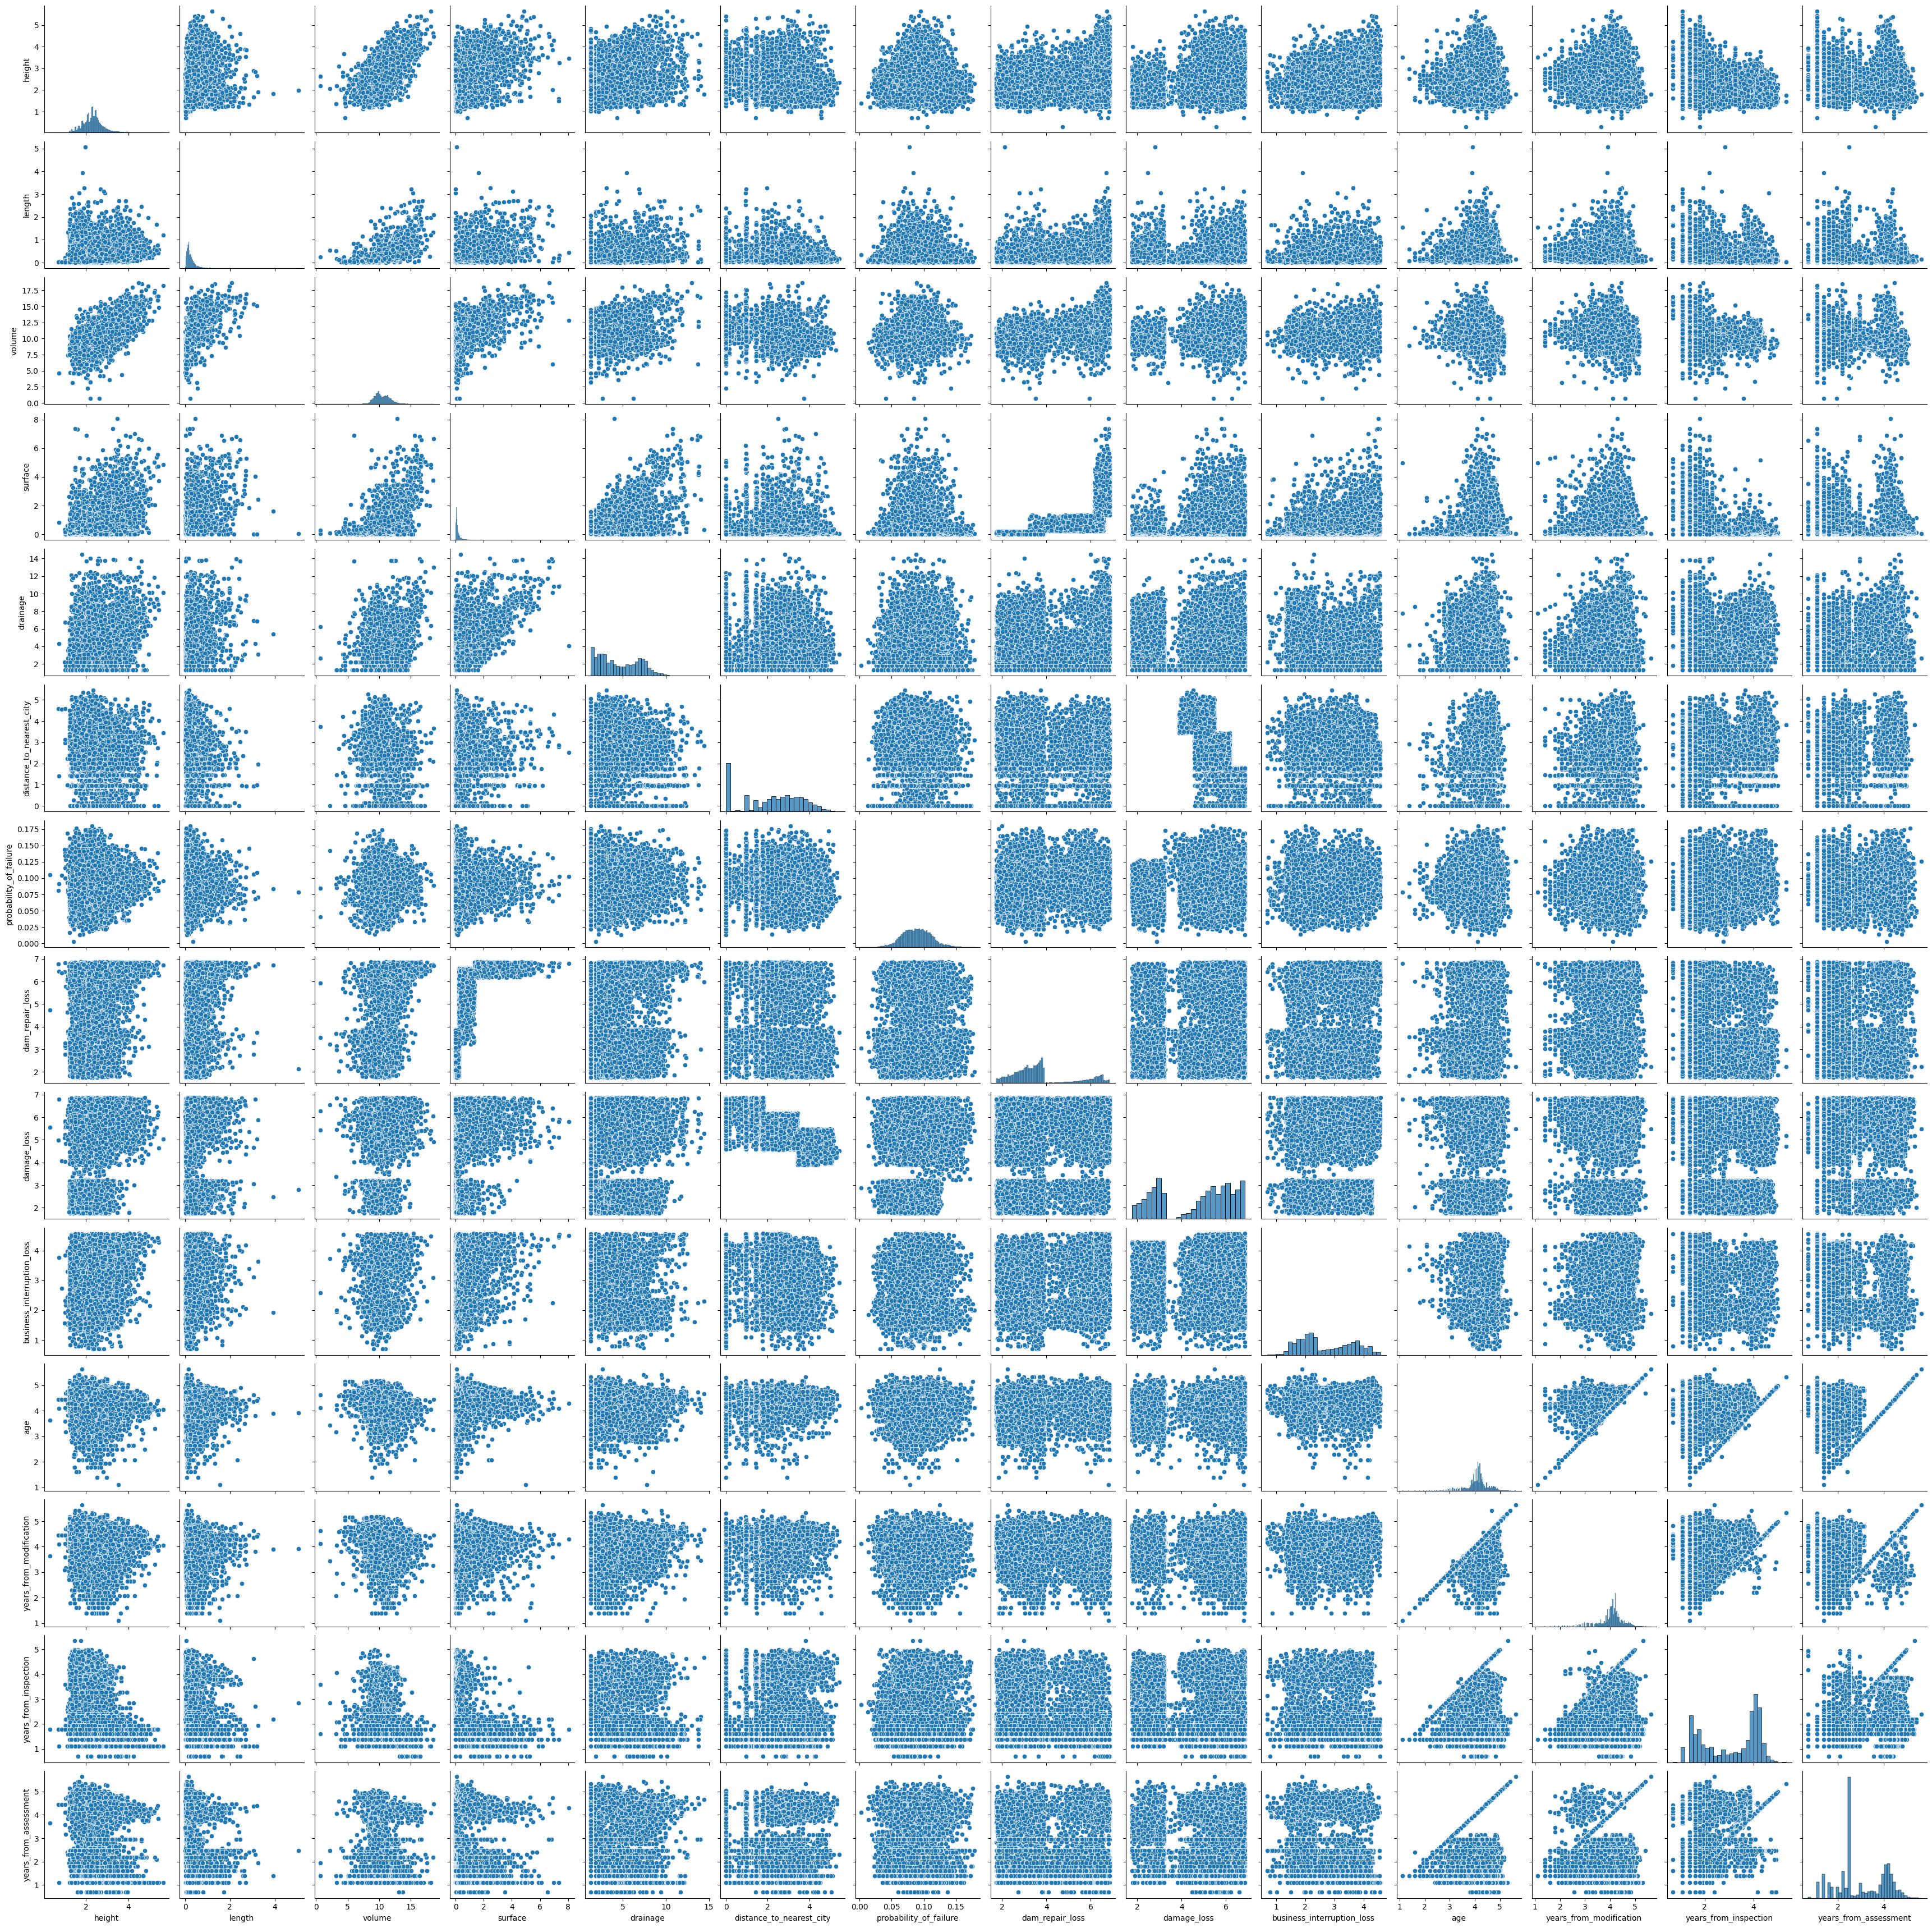

In [ ]:
plt.figure(figsize=(100,80))
sns.pairplot(data=pair_df)
plt.savefig('../plot/log_pair_plot.png')

In [ ]:
outliers_removed_df = df.loc[(df[feature] < df[feature].quantile(0.01)) | df[feature]]

In [6]:
df['regulated_dam'].value_counts()

Yes    12052
No      8754
Name: regulated_dam, dtype: int64

In [10]:
df.loc[df['regulated_dam'] != 'No']['damage_loss'].describe()

count    12052.000000
mean       309.994366
std        275.392865
min          4.800000
25%         75.825000
50%        225.850000
75%        479.300000
max        953.900000
Name: damage_loss, dtype: float64

In [9]:
df.loc[df['regulated_dam'] != 'Yes']['damage_loss'].describe()

count    8742.000000
mean      176.035587
std       239.050256
min         4.800000
25%        13.400000
50%        22.100000
75%       286.250000
max       953.300000
Name: damage_loss, dtype: float64

In [42]:
df.groupby('region')[['dam_repair_loss', 'damage_loss', 'business_interruption_loss']].sum().T.sum()

region
Flumevale     2035712.1
Lyndrassia    2773335.0
Navaldia      3238899.8
dtype: float64

In [44]:
loss_df = pd.DataFrame(data={
    'loss': [2035712.1, 2773335.0, 3238899.8],
    'GDP': [4197489, 480201, 3396363]
})

<Axes: >

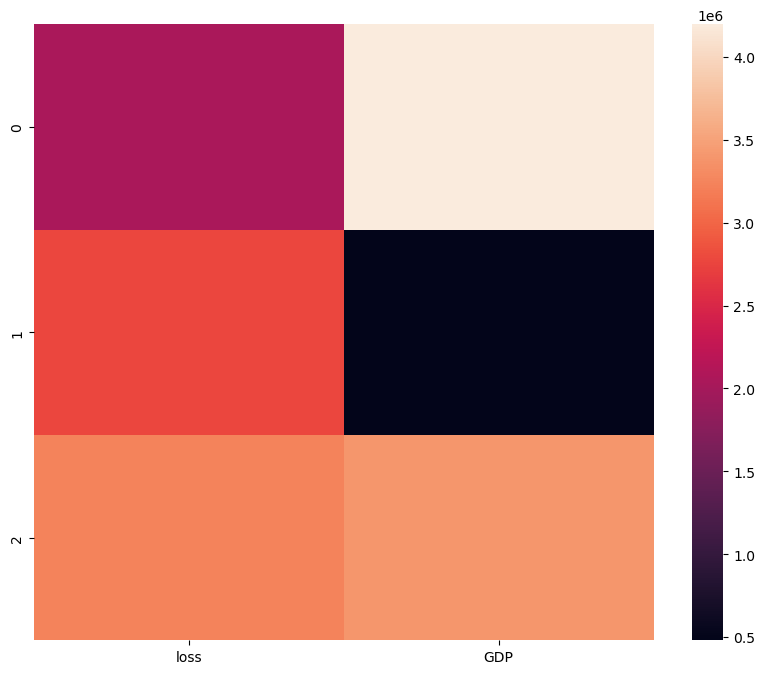

In [45]:
plt.figure(figsize=(10,8))
sns.

In [54]:
df['damage_loss'].mean()

123.11719794220876

In [55]:
df[df['surface'] < df['surface'].quantile(0.01)]['damage_loss'].mean()

316.75384615384627